In [12]:
!pip install numpy pandas
!pip install matplotlib
!pip install torch

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
    --------------------------------------- 2.6/114.6 MB 13.0 MB/s eta 0:00:09
   - -------------------------------------- 5.0/114.6 MB 13.0 MB/s eta 0:00:09
   -- ------------------------------------- 7.9/114.6 MB 12.9 MB/s eta 0:00:09
   --- ------------------------------------ 10.5/114.6 MB 12.9 MB/s eta 0:00:09
   ---- ----------------------------------- 13.1/114.6 MB 12.9 MB/s eta 0:00:08
   ----- ---------------------------------- 15.7/114.6 MB 12.9 MB/s eta 0:00:08
   ------ --------------------------------- 18.4/114.6 MB 12.9 MB/s eta 0:00:08
   ------- -------------------------------- 21.0/114.6 MB 12.9 MB/s eta 0:00:08
   -------- ------------------------------- 23.6/114.6 MB 12.9 MB/s eta 0:00:08
   --------- ------------------------------ 26.2/114.6 MB 12.9 MB/s eta 0:00:07
   ---------- ----------------------------- 28.8/114.6 MB 12.9 MB/s eta 0:00:07
   ---------- ----------------------------- 31.5/114

In [16]:
import numpy as np
import pandas as pd

g = -9.8          # Schwerkraft
dt = 0.01         # Zeitschritt
steps = 500       # Schritte pro Simulation

data = []        

# simulieren
for sim in range(30):

    x = np.random.uniform(0.5, 3.0)     # Höhe
    v = np.random.uniform(-1.0, 1.0)    # Geschwindigkeit
    restitution = np.random.uniform(0.6, 0.9)  # wie stark er zurückspringt

    for t in range(steps):
        x_old = x
        v_old = v

        v = v + g * dt
        x = x + v * dt

        if x <= 0:
            x = 0
            v = -restitution * v

        x_next = x
        v_next = v

        data.append([x_old, v_old, x_next, v_next])

df = pd.DataFrame(data, columns=["x", "v", "x_next", "v_next"])

# speichern als Datei
df.to_csv("bouncing_ball_data.csv", index=False)

print(len(df))
print("Datensatz gespeichert!")

15000
Datensatz gespeichert!


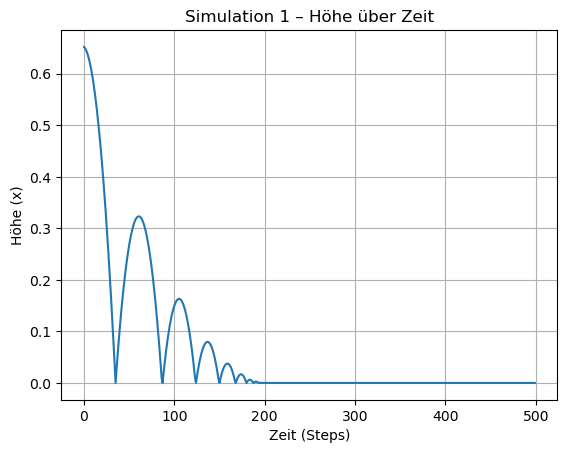

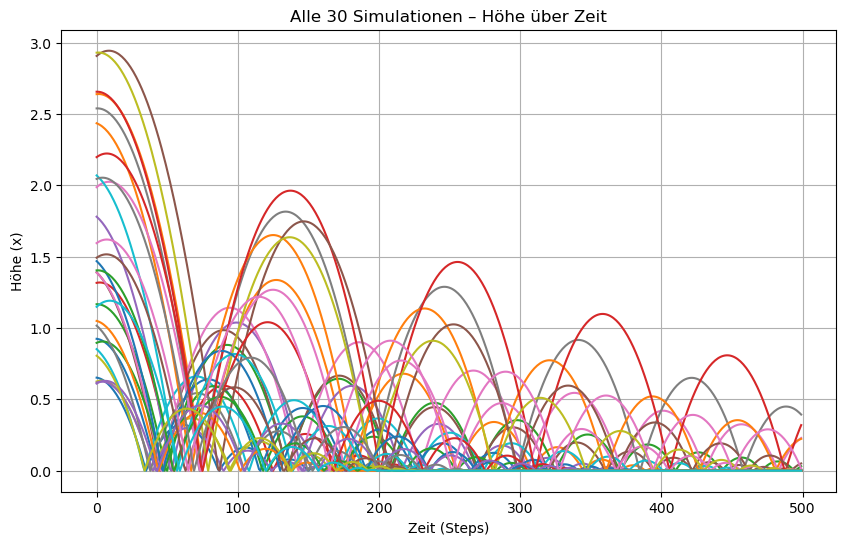

In [17]:
import matplotlib.pyplot as plt

sim1 = df.iloc[:500]
time = range(len(sim1))

plt.plot(time, sim1["x"])
plt.xlabel("Zeit (Steps)")
plt.ylabel("Höhe (x)")
plt.title("Simulation 1 – Höhe über Zeit")
plt.grid()

plt.show()

steps_per_sim = 500
num_sims = 30

plt.figure(figsize=(10, 6))

for sim in range(num_sims):
    start = sim * steps_per_sim
    end = (sim + 1) * steps_per_sim
    
    sim_data = df.iloc[start:end]
    time = range(len(sim_data))
    
    plt.plot(time, sim_data["x"], label=f"Sim {sim+1}")

plt.xlabel("Zeit (Steps)")
plt.ylabel("Höhe (x)")
plt.title("Alle 30 Simulationen – Höhe über Zeit")
plt.grid()

plt.show()

In [19]:
split = int(0.8 * len(df))

train_df = df.iloc[:split]

test_df = df.iloc[split:]

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim

X_train = torch.tensor(train_df[["x", "v"]].values, dtype=torch.float32)
y_train = torch.tensor(train_df[["x_next", "v_next"]].values, dtype=torch.float32)

X_test = torch.tensor(test_df[["x", "v"]].values, dtype=torch.float32)
y_test = torch.tensor(test_df[["x_next", "v_next"]].values, dtype=torch.float32)

model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

mse_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 3000

for epoch in range(epochs):
    y_pred = model(X_train)
    mse = mse_fn(y_pred, y_train)

    optimizer.zero_grad()
    mse.backward()
    optimizer.step()

# =========================
# Evaluation
# =========================
with torch.no_grad():
    y_test_pred = model(X_test)

    mse_total = mse_fn(y_test_pred, y_test).item()

    x_t = X_test[:, 0]

    mask_impact = x_t <= 0.01
    mask_mid = (x_t > 0.01) & (x_t <= 0.1)
    mask_far = x_t > 0.1

    mse_impact = mse_fn(y_test_pred[mask_impact], y_test[mask_impact]).item()
    mse_mid = mse_fn(y_test_pred[mask_mid], y_test[mask_mid]).item()
    mse_far = mse_fn(y_test_pred[mask_far], y_test[mask_far]).item()

print("\n--- Ergebnisse ---")
print(f"Gesamt MSE:         {mse_total:.6f}")
print(f"MSE Boden:         {mse_impact:.6f}")
print(f"MSE Zwischenbereich bzw. hier interessant (s. Ergebnisse):{mse_mid:.6f}")
print(f"MSE kein Boden:{mse_far:.6f}")


--- Ergebnisse ---
Gesamt MSE:         0.043646
MSE Impact:         0.007316
MSE Zwischenbereich:0.293490
MSE Far from impact:0.002984


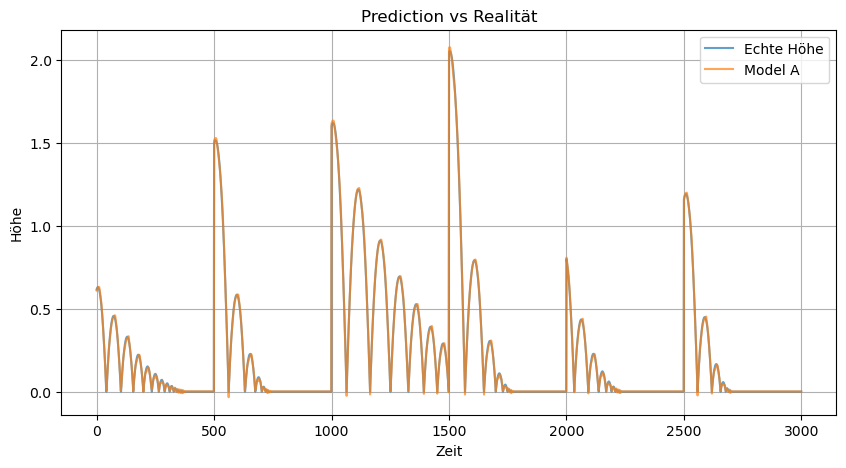

In [30]:
# Plot 1

y_test_np = y_test.numpy()
y_pred_a_np = y_test_pred_a.numpy()
y_pred_b_np = y_test_pred_b.numpy()

time = range(len(y_test_np))

plt.figure(figsize=(10, 5))
plt.plot(time, y_test_np[:, 0], label="Echte Höhe", alpha=0.7)
plt.plot(time, y_pred_a_np[:, 0], label="Model A", alpha=0.7)
plt.xlabel("Zeit")
plt.ylabel("Höhe")
plt.title("Prediction vs Realität")
plt.legend()
plt.grid()
plt.show()
